## [✔] COMPLETO

# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [1]:
import pandas as pd
import numpy as np
import time
from Bio import Entrez
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_genes = pd.read_csv("./data/df_genes_aula6exer7.csv", index_col="Unnamed: 0")
df_genes.head()

,num_letras,primeiras_duas_letras,num_a,contains_hu
isg15,5,is,0,False
hur,3,hu,0,True
ifna,4,if,1,False
tnfa,4,tn,1,False
atpsf1a,7,at,2,False


In [3]:
df_genes['id_entrez'] = [
    "NM_005101.4",
    "NM_001419.3",
    "NM_024013.3",
    "NM_001270508.2",
    "NM_004046.6",
]

df_genes['id_protein'] = [
    'NP_005092.1',
    "NP_001410.2",
    "NP_000596.2",
    "NP_001257437.1",
    "NP_004037.1",
]
df_genes

,num_letras,primeiras_duas_letras,num_a,contains_hu,id_entrez,id_protein
isg15,5,is,0,False,NM_005101.4,NP_005092.1
hur,3,hu,0,True,NM_001419.3,NP_001410.2
ifna,4,if,1,False,NM_024013.3,NP_000596.2
tnfa,4,tn,1,False,NM_001270508.2,NP_001257437.1
atpsf1a,7,at,2,False,NM_004046.6,NP_004037.1


In [4]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "hectorfurini@outlook.com"

    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"./data/{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [5]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index 
    salvar_fasta_gene(id_protein=id_gene, nome_gene=nome_gene)
    time.sleep(10)  # Para evitar sobrecarga no servidor do NCBI
    print(nome_gene, id_gene)

isg15 NP_005092.1
hur NP_001410.2
ifna NP_000596.2
tnfa NP_001257437.1
atpsf1a NP_004037.1


Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [9]:
# Lê os fasta e guarda em um dicionário
dict_genes_seq = {}
for gene in df_genes.index:
    with open(f"./data/{gene}.fasta", "r") as infile:
        data = infile.readlines()
        data.pop(0) # Removes first line (header)
        data = "".join(data).replace("\n", "") # Join sequences and removes \n
        dict_genes_seq[gene] = data # Append to dict

# Usar o dicionario mapeando genes pelo nome para adicionar a sequencia no DataFrame

df_genes_seq = df_genes.drop(columns=["num_letras", "primeiras_duas_letras", "num_a", "contains_hu"])

df_genes_seq["amn_sequence"] = df_genes_seq.index.map(dict_genes_seq)

df_genes_seq

,id_entrez,id_protein,amn_sequence
isg15,NM_005101.4,NP_005092.1,MGWDLTVKMLAGNEFQVSLSSSMSVSELKAQITQKIGVHAFQQRLA...
hur,NM_001419.3,NP_001410.2,MSNGYEDHMAEDCRGDIGRTNLIVNYLPQNMTQDELRSLFSSIGEV...
ifna,NM_024013.3,NP_000596.2,MALTFALLVALLVLSCKSSCSVGCDLPQTHSLGSRRTLMLLAQMRR...
tnfa,NM_001270508.2,NP_001257437.1,MAEQVLPQALYLSNMRKAVKIRERTPEDIFKPTNGIIHHFKTMHRY...
atpsf1a,NM_004046.6,NP_004037.1,MLSVRVAAAVVRALPRRAGLVSRNALGSSFIAARNFHASNTHLQKT...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [165]:
df_amn_count = pd.DataFrame()

for index in df_genes_seq.index:
    gene_name = index
    amn_list = list(df_genes_seq.loc[index, "amn_sequence"])
    counts = pd.Series(amn_list).value_counts()
    df_amn_count[gene_name] = counts.astype(int)

df_amn_count = df_amn_count.T
df_amn_count
    

,L,G,V,S,Q,E,T,P,K,R,D,A,F,M,N,I,H,W,Y,C
isg15,24.0,18.0,16.0,15.0,12.0,9.0,9.0,8.0,8.0,8.0,7.0,7.0,5.0,4.0,4.0,3.0,3.0,2.0,2.0,1.0
hur,22.0,29.0,22.0,28.0,12.0,15.0,16.0,12.0,18.0,20.0,16.0,23.0,18.0,10.0,23.0,19.0,8.0,2.0,10.0,3.0
ifna,27.0,6.0,10.0,18.0,12.0,14.0,11.0,5.0,11.0,10.0,8.0,11.0,11.0,6.0,4.0,8.0,3.0,2.0,5.0,6.0
tnfa,64.0,45.0,29.0,53.0,39.0,57.0,47.0,56.0,46.0,56.0,30.0,50.0,34.0,20.0,40.0,27.0,30.0,9.0,18.0,40.0
atpsf1a,53.0,51.0,46.0,39.0,25.0,31.0,27.0,18.0,30.0,38.0,29.0,58.0,16.0,12.0,16.0,39.0,7.0,NaN,16.0,2.0


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [37]:
display(df_amn_count.loc[:, "V"].sort_values(ascending=False))


atpsf1a    46.0
tnfa       29.0
hur        22.0
isg15      16.0
ifna       10.0
Name: V, dtype: float64

## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [44]:
print("Média:", df_amn_count.loc[:, "S"].mean())
print("Mediana:", df_amn_count.loc[:, "S"].median())
print("Moda:", df_amn_count.loc[:, "S"].mode())

Média: 30.6
Mediana: 28.0
Moda: 0    15.0
1    18.0
2    28.0
3    39.0
4    53.0
Name: S, dtype: float64


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

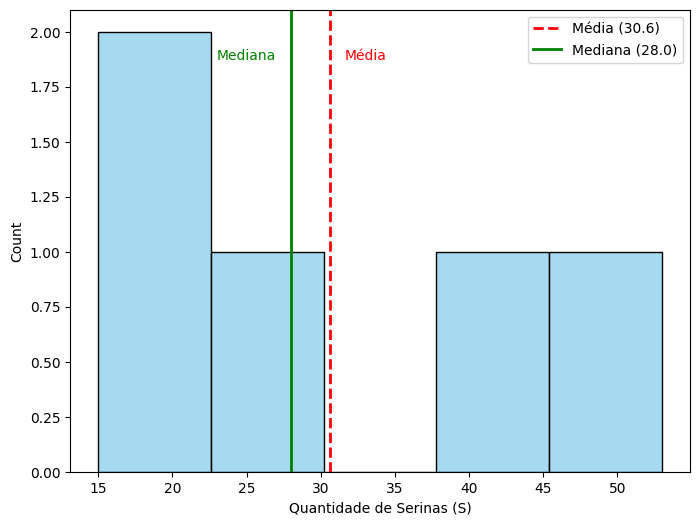

In [68]:
media_serina = df_amn_count.loc[:, "S"].mean()
mediana_serina = df_amn_count.loc[:, "S"].median()

plt.figure(figsize=(8, 6))

sns.histplot(data=df_amn_count, x="S", bins=5, color="skyblue", edgecolor="black")

# Adicionando as linhas verticais para a média e a mediana
plt.axvline(media_serina, color='red', linestyle='dashed', linewidth=2, label=f'Média ({media_serina:.1f})')
plt.axvline(mediana_serina, color='green', linestyle='solid', linewidth=2, label=f'Mediana ({mediana_serina:.1f})')

# Adicionando textos explicativos perto das linhas
ax = plt.gca()
y_pos = ax.get_ylim()[1] * 0.9
plt.text(media_serina + 1, y_pos, 'Média', color='red', va='center', ha='left')
plt.text(mediana_serina - 1, y_pos, 'Mediana', color='green', va='center', ha='right')

plt.xlabel('Quantidade de Serinas (S)')
plt.legend()
plt.show()

### Alternativa ao histograma -> barplot

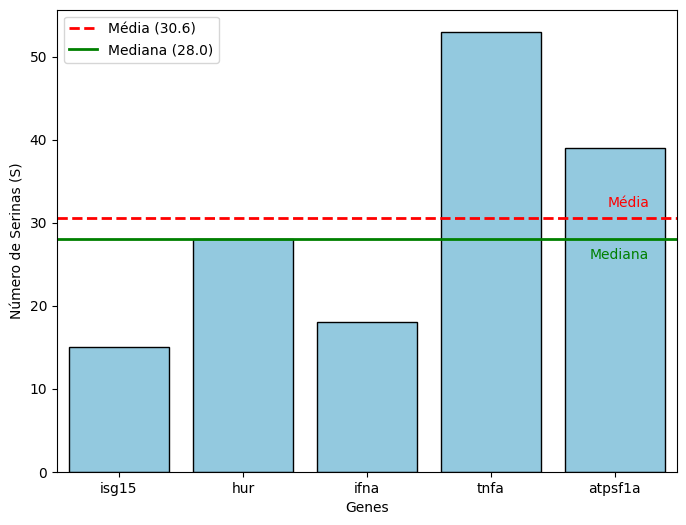

In [71]:
plt.figure(figsize=(8, 6))

sns.barplot(x=df_amn_count.index, y=df_amn_count["S"], color="skyblue", edgecolor="black")

# Adicionando as linhas horizontais (axhline) para a média e a mediana
plt.axhline(media_serina, color='red', linestyle='dashed', linewidth=2, label=f'Média ({media_serina:.1f})')
plt.axhline(mediana_serina, color='green', linestyle='solid', linewidth=2, label=f'Mediana ({mediana_serina:.1f})')

# Ajustando a posição dos textos no eixo X (colocando perto da borda direita)
ax = plt.gca()
x_pos = ax.get_xlim()[1] * 0.95
plt.text(x_pos, media_serina + 1, 'Média', color='red', va='bottom', ha='right')
plt.text(x_pos, mediana_serina - 1, 'Mediana', color='green', va='top', ha='right')

# Configurando rótulos e título
plt.xlabel('Genes')
plt.ylabel('Número de Serinas (S)')
plt.legend()

# Exibindo o gráfico
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [116]:
def geraBarplot(aa: str, df: pd.DataFrame):
    aminoacidos = {
    'alanina': 'A', 'arginina': 'R', 'asparagina': 'N', 'aspartato': 'D',
    'cisteina': 'C', 'glutamina': 'Q', 'glutamina': 'E', 'glicina': 'G',
    'histidina': 'H', 'isoleucina': 'I', 'leucina': 'L', 'lisina': 'K',
    'metionina': 'M', 'fenilalanina': 'F', 'prolina': 'P', 'serina': 'S',
    'treonina': 'T', 'triptofano': 'W', 'tirosina': 'Y', 'valina': 'V'
    }
    
    try:
        letra_aa = aminoacidos.get(aa.casefold(), None)
    except KeyError:
        return f"{aa} não encontrado no DataFrame."
    
    media_aa = df[letra_aa].mean()
    mediana_aa = df[letra_aa].median()

    plt.figure(figsize=(8, 6))
    sns.barplot(x=df.index, y=df[letra_aa], color="skyblue", edgecolor="black")

    plt.axhline(media_aa, color='red', linestyle='dashed', linewidth=2, label=f'Média ({media_aa:.1f})')
    plt.axhline(mediana_aa, color='green', linestyle='solid', linewidth=2, label=f'Mediana ({mediana_aa:.1f})')

    ax = plt.gca()
    x_pos = ax.get_xlim()[1] * 0.95
    plt.text(x_pos, media_aa + 1, 'Média', color='red', va='bottom', ha='right')
    plt.text(x_pos, mediana_aa - 1, 'Mediana', color='green', va='top', ha='right')

    plt.xlabel('Genes')
    plt.ylabel(f'Número de {aa}({letra_aa})')
    plt.legend()

    return plt.show()

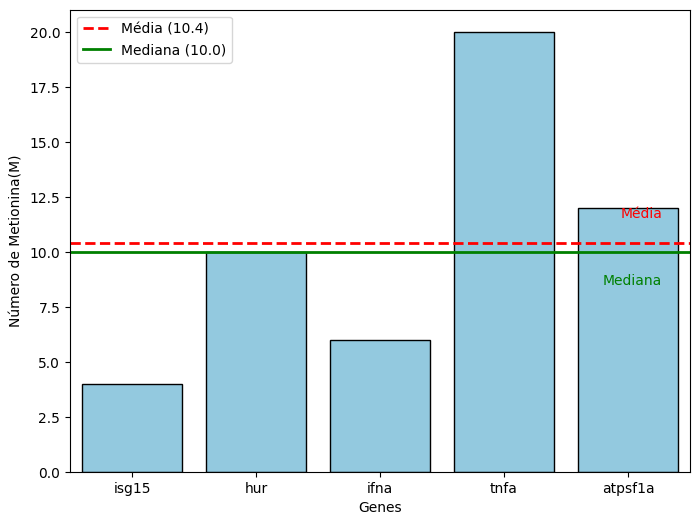

In [118]:
geraBarplot("Metionina", df_amn_count)

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

R.: A Glicina tem a menor diferença

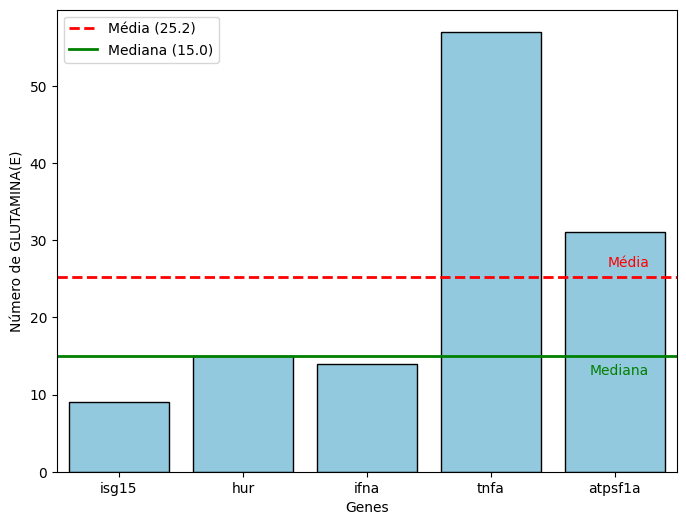

In [119]:
geraBarplot("GLUTAMINA", df_amn_count)

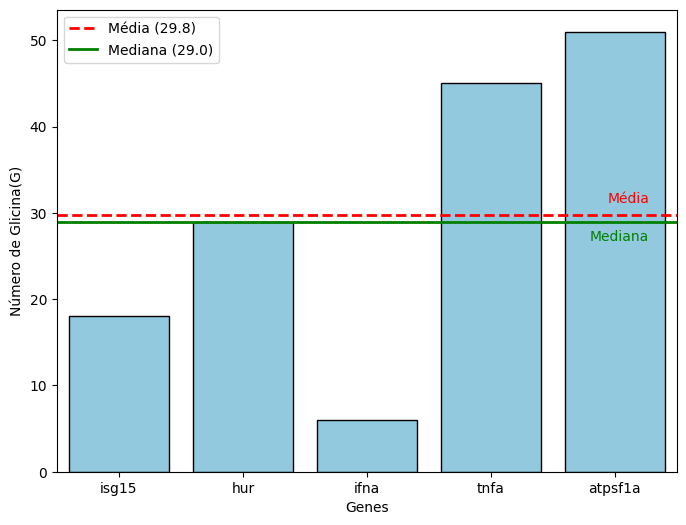

In [120]:
geraBarplot("Glicina", df_amn_count)

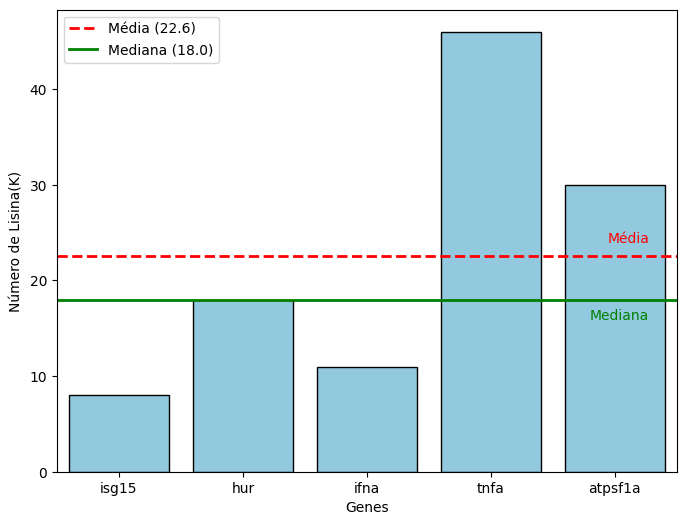

In [121]:
geraBarplot("Lisina", df_amn_count)

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [162]:
primeiros_tres_genes = df_amn_count.index[:3]

column = pd.Series(df_amn_count.loc[primeiros_tres_genes, "C"])

display(column)
print(f"Média: {column.mean().round(3)}\nMediana: {column.median()}")

isg15    1.0
hur      3.0
ifna     6.0
Name: C, dtype: float64

Média: 3.333
Mediana: 3.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

R.: Baseado no número médio de aminoácidos o maior gene seria o _"tnfa"_

In [163]:
for index in df_amn_count.index:
    display(index, df_amn_count.loc[index, :].mean())

'isg15'

8.25

'hur'

16.3

'ifna'

9.4

'tnfa'

39.5

'atpsf1a'

29.105263157894736

## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

R.: Baseado no número médio de aminoácidos o menor gene seria o _"isg15"_
